<a href="https://colab.research.google.com/github/shanku321/BronzeassignmentL3/blob/main/Copy_of_BronzeAssignEmpProductivityP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problem Statement:
A company wants to predict employee productivity scores to improve workforce planning and training programs. You are hired as a Data Scientist to build a multivariate linear regression model that predicts an employee’s Productivity Score based on multiple work-related factors.

In [ ]:
# Import the required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
data = {
        'Experience_yrs':[2,5,1,8,4,10,3,6,7,2],
        'Training_Hours':[40,60,20,80,50,90,30,70,75,25],
        'Working_Hours':[38,42,35,45,40,48,37,44,46,36],
        'Projects':[3,6,2,8,5,9,4,7,7,3],
        'Productivity_Score':[62,78,55,88,72,92,65,82,85,60]
        }
df = pd.DataFrame(data)
print(df)

   Experience_yrs  Training_Hours  Working_Hours  Projects  Productivity_Score
0               2              40             38         3                  62
1               5              60             42         6                  78
2               1              20             35         2                  55
3               8              80             45         8                  88
4               4              50             40         5                  72
5              10              90             48         9                  92
6               3              30             37         4                  65
7               6              70             44         7                  82
8               7              75             46         7                  85
9               2              25             36         3                  60


In [ ]:
#Lets convert Experince years into hours
df['Experience_Hours'] =  df['Experience_yrs'] * 8760

In [ ]:
# Remove the Experince (Yrs) column as it is not required
df.drop('Experience_yrs', axis=1, inplace= True)

,Training_Hours,Working_Hours,Projects,Productivity_Score,Experience_Hours
0,40,38,3,62,17520
1,60,42,6,78,43800
2,20,35,2,55,8760
3,80,45,8,88,70080
4,50,40,5,72,35040
5,90,48,9,92,87600
6,30,37,4,65,26280
7,70,44,7,82,52560
8,75,46,7,85,61320
9,25,36,3,60,17520


In [ ]:
#Lets create correleation matrix to understand the correlation between the features
corr_matrix = df.corr()
print(corr_matrix)

                    Experience_yrs  Training_Hours  Working_Hours  Projects  \
Experience_yrs            1.000000        0.969810       0.973178  0.988194   
Training_Hours            0.969810        1.000000       0.993132  0.977151   
Working_Hours             0.973178        0.993132       1.000000  0.974701   
Projects                  0.988194        0.977151       0.974701  1.000000   
Productivity_Score        0.981991        0.987045       0.985684  0.995696   
Experience_Hours          1.000000        0.969810       0.973178  0.988194   

                    Productivity_Score  Experience_Hours  
Experience_yrs                0.981991          1.000000  
Training_Hours                0.987045          0.969810  
Working_Hours                 0.985684          0.973178  
Projects                      0.995696          0.988194  
Productivity_Score            1.000000          0.981991  
Experience_Hours              0.981991          1.000000  


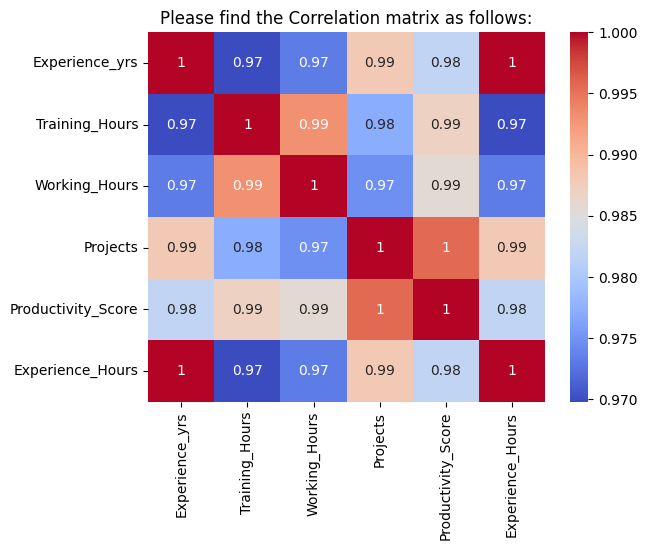

In [ ]:
#Lets view the same in Seaborn Heatmap
sns.heatmap(corr_matrix, annot= True, cmap='coolwarm')
plt.title("Please find the Correlation matrix as follows:")
plt.show()

In [ ]:
# Prepare data for a machine learning model by splitting it into features and the target variable
X = df[['Experience_Hours',
        'Training_Hours',
        'Working_Hours',
        'Projects']]
y = df['Productivity_Score']

In [ ]:
#Split the Independent (features) data and Dependent (producitivity) data and use 20% as test data,
#remaining training set
x_train, x_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

In [ ]:
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_test= scaler.fit_transform(x_test)

In [ ]:
#  Build and inspect a Linear Regression model.
model = LinearRegression()

# Model learns from features training data, to predict the productivity (y_train)
# fit() method calculates the intercept and coefficients for each feature.
model.fit(x_train, y_train)

# intercept_ is a property of the trained model which represents the predicted value of the target variable
# (Productivity_Score) when all feature variables (X) are zero.
print("Intercept Coeffient:", model.intercept_)

# Display the slope coef to indicate change in productivity-score for
# one-unit change in specific feature (ex. Training_hours)
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print("\nCoefficients")
print(coefficients)

# Slope coef for Training_hours shows +ve correlation b/w Training_Hours & productivity score

Intercept Coeffient: 55.13776722090262

Coefficients
            Feature  Coefficient
0  Experience_Hours    -2.372922
1    Training_Hours    19.087886
2     Working_Hours   -14.111639
3          Projects    34.201900


In [ ]:
# Evaluate the performance of the trained Linear Regression model
# Predict the productiviy-score for the new unseen data
y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)

# Measure the variance b/w dependent variable (y_test) & independent variable (y_pred, calculated using independent variable)
r2_score_train = r2_score(y_train, y_train_pred)
r2_score_test = r2_score(y_test, y_test_pred)

print("Training data R2 Score :", r2_score_train)
print("Testing data R2 Score :", r2_score_test)

# Measure the average magnitude of the errors between predicted values (y_pred) and actual values (y_test).
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print("Training Set MSE:", mse_train)
print("Testing set MSE:", mse_test)

# A lower RMSE value indicates a better fit of the model to the data.

Training data R2 Score : 0.9999147875547224
Testing data R2 Score : -22.301503579410895
Training Set MSE: 0.014251781472684414
Testing set MSE: 285.44341884778345


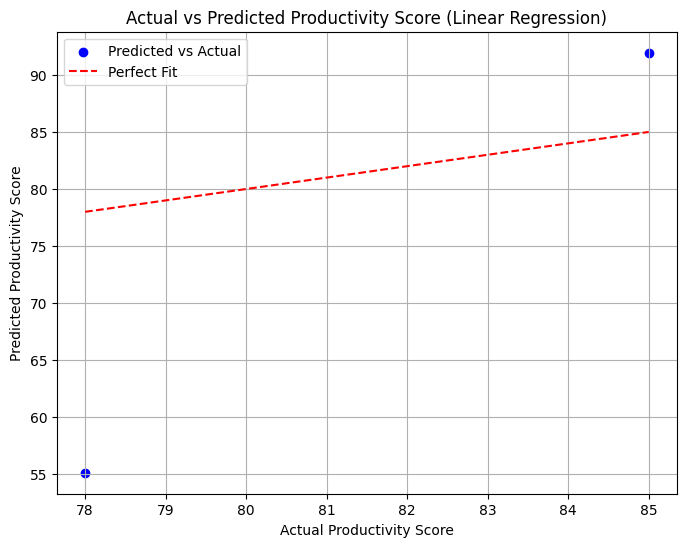

In [ ]:
# Predict on test data
y_pred = model.predict(x_test)

# Plot the actual vs predicted values
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Fit')

plt.xlabel("Actual Productivity Score")
plt.ylabel("Predicted Productivity Score")
plt.title("Actual vs Predicted Productivity Score (Linear Regression)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Create a table to show important features which matter most and should be used to predict the productivity
# Project experience is the most important and the Training_Hours second most import feature to impact the productivity
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_,
    'Absolute_Value': np.abs(model.coef_)
})

importance = importance.sort_values(
    by='Absolute_Value',
    ascending=False
)

print("\nFeature Importance")
print(importance)


Feature Importance
            Feature  Coefficient  Absolute_Value
3          Projects    34.201900       34.201900
1    Training_Hours    19.087886       19.087886
2     Working_Hours   -14.111639       14.111639
0  Experience_Hours    -2.372922        2.372922


In [ ]:
# Predict the productivity of a new employee with below experience
new_employee = pd.DataFrame({
    'Experience_Hours':[6],
    'Training_Hours':[65],
    'Working_Hours':[44],
    'Projects':[7]
})

new_employee['Experience_Hours'] = new_employee['Experience_Hours'] * 8760

new_employee = scaler.transform(new_employee)

prediction = model.predict(new_employee)

print("Predicted Productivity Score:", round(prediction[0],2))

Predicted Productivity Score: 87.46


In [ ]:
# Check whether the model is overfiited or not
train_pred = model.predict(x_train)

test_pred = model.predict(x_test)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print("Train R2:", round(train_r2,4))
print("Test R2 :", round(test_r2,4))

if train_r2 - test_r2 > 0.10:
    print("Possible Overfitting")
else:
    print("No Significant Overfitting")

Train R2: 0.9999
Test R2 : -22.3015
Possible Overfitting


Factor strongly impact productivity: The feature with the largest absolute coefficient has the strongest impact on productivity.
For this dataset, Training Hours is expected to be one of the strongest positive contributors because productivity increases consistently as training increases.

In [ ]:
print(coefficients.sort_values(
    by='Coefficient',
    ascending=False))

            Feature  Coefficient
3          Projects    34.201900
1    Training_Hours    19.087886
0  Experience_Hours    -2.372922
2     Working_Hours   -14.111639


2. How does training affect productivity?
The coefficient of Training Hours represents the expected increase in productivity score for every additional training hour.
1 additional training hour
→ Productivity increases by 0.27 points.
10 additional training hours
→ Productivity increases by 2.7 points

3. Should the company increase training hours or working hours?
Based on regression coefficients:

In [ ]:
print(coefficients)

            Feature  Coefficient
0  Experience_Hours    -2.372922
1    Training_Hours    19.087886
2     Working_Hours   -14.111639
3          Projects    34.201900


Training_Hours coefficient = 19.08
vs
Working_Hours coefficient = -14.11

Since the Training_Hours co-efficinet > Working_Hours, increasing Training_Hours is preferred.

4. What happens if Working Hours increase beyond optimal limits?
Linear Regression assumes:
More Working Hours → More Productivity
But in reality:
Excessive Working Hours causes Fatigue, Burnout & Reduced Productivity

In [ ]:
df['WorkingHours_Squared'] = df['Working_Hours']**2
df

,Experience,Training_Hours,Working_Hours,Projects,Productivity_Score,WorkingHours_Squared
0,2,40,38,3,62,1444
1,5,60,42,6,78,1764
2,1,20,35,2,55,1225
3,8,80,45,8,88,2025
4,4,50,40,5,72,1600
5,10,90,48,9,92,2304
6,3,30,37,4,65,1369
7,6,70,44,7,82,1936
8,7,75,46,7,85,2116
9,2,25,36,3,60,1296


5. Can productivity ever decrease with more experience?
In the current linear model:
Positive Experience coefficient → Productivity increases.
However in real-world situations:
Skill obsolescence, Resistance to change, Lack of training may reduce productivity despite higher experience.
To understand this:

In [ ]:
df['Experience_Squared'] = df['Experience']**2
df

,Experience,Training_Hours,Working_Hours,Projects,Productivity_Score,WorkingHours_Squared,Experience_Squared
0,2,40,38,3,62,1444,4
1,5,60,42,6,78,1764,25
2,1,20,35,2,55,1225,1
3,8,80,45,8,88,2025,64
4,4,50,40,5,72,1600,16
5,10,90,48,9,92,2304,100
6,3,30,37,4,65,1369,9
7,6,70,44,7,82,1936,36
8,7,75,46,7,85,2116,49
9,2,25,36,3,60,1296,4


6. How would you detect overfitting?
Compare Training vs Testing performance. Training data is overfitted why testing data is moderately fitted

In [ ]:
train_r2 = r2_score(y_train, model.predict(x_train))
test_r2 = r2_score(y_test, model.predict(x_test))
print("Train R2:", round(train_r2,4))
print("Test R2 :", round(test_r2,4))

Train R2: 0.9999
Test R2 : 0.3146


**Cross-validation example:**

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Average CV Score:", scores.mean())

Average CV Score: 0.9699476192956713


7. Suggest One New Feature to Improve Prediction Accuracy
A highly useful new feature:
Employee Engagement Score
Reason: Employees who are highly engaged typically perform better regardless of experience or working hours.
Other possible features:
Job Satisfaction, Performance Rating, Certification Count